# 11 - Phase 2 Visualisations

Produce Phase 2 plots: subgoal completion curves, reward ablation bars, oracle trajectory, and a learned-agent key -> door -> goal rollout.

In [7]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.env import DoorKeyMazeEnv
from src.utils.io import DIRS, figure_path

plt.rcParams["figure.figsize"] = (8, 4)
COLORS = {"key": "#40a02b", "door": "#fe640b", "goal": "#8839ef", "dqn": "#1f77b4", "ddqn": "#ff7f0e", "ppo": "#2ca02c"}

## Load Phase 2 Metric Files

In [8]:
MODE = "quick"  # use "quick" for current saved run; change to "full" after full training

def parse_run_id(run_id):
    parts = run_id.split("_")
    return {"mode": parts[1], "algo": parts[2], "reward": parts[3], "level": parts[4], "difficulty": parts[5], "seed": int(parts[6].replace("seed", ""))}

def load_runs(mode=MODE):
    runs = []
    for path in sorted(DIRS["metrics"].glob("p2_*_metrics.npz")):
        run_id = path.name.replace("_metrics.npz", "")
        meta = parse_run_id(run_id)
        if meta["mode"] != mode:
            continue
        data = np.load(path)
        runs.append({"run_id": run_id, **meta, **{k: data[k] for k in data.files}})
    return runs

runs = load_runs()
print("loaded", len(runs), "runs")
print("available:", sorted({(r["algo"], r["reward"], r["seed"]) for r in runs}))

loaded 5 runs
available: [('ddqn', 'potential', 0), ('ddqn', 'sparse', 0), ('ddqn', 'subgoal', 0), ('dqn', 'subgoal', 0), ('ppo', 'subgoal', 0)]


## V7 - Subgoal Completion Curves

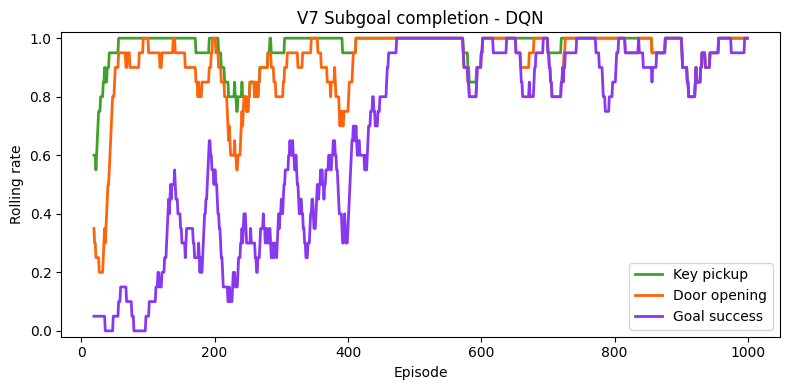

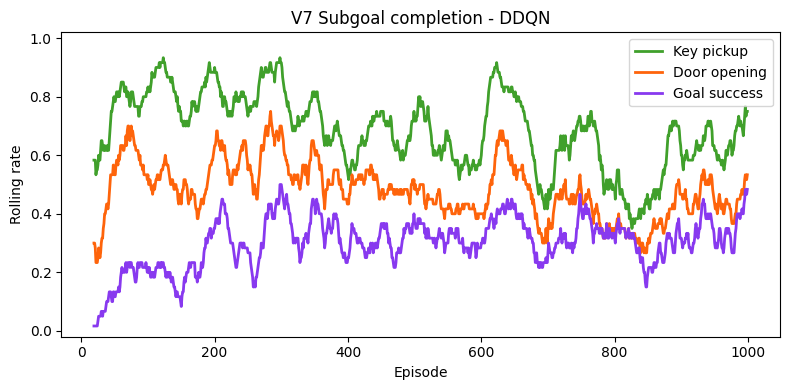

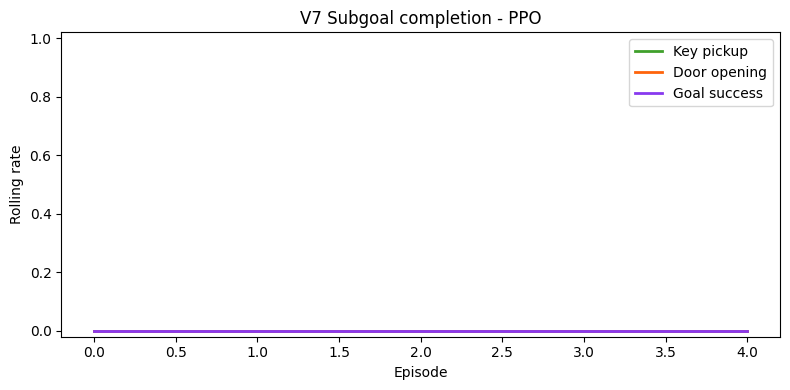

In [9]:
def rolling_mean(x, window=20):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    if len(x) == 0:
        return out
    window = max(1, min(window, max(1, len(x) // 5), len(x)))
    out[window - 1:] = np.convolve(x, np.ones(window) / window, mode="valid")
    return out

def plot_subgoal_curves(runs, algo, reward=None):
    selected = [r for r in runs if r["algo"] == algo and (reward is None or r["reward"] == reward)]
    if not selected:
        print("no runs for", algo, reward)
        return None
    min_len = min(len(r["success"]) for r in selected)
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, key, color in [("Key pickup", "key", COLORS["key"]), ("Door opening", "door", COLORS["door"]), ("Goal success", "success", COLORS["goal"])]:
        mat = np.stack([r[key][:min_len] for r in selected])
        ax.plot(rolling_mean(mat.mean(axis=0)), label=label, color=color, linewidth=2)
    ax.set_title(f"V7 Subgoal completion - {algo.upper()}" + (f" / {reward}" if reward else ""))
    ax.set_xlabel("Episode")
    ax.set_ylabel("Rolling rate")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    fig.tight_layout()
    return fig

for algo in ["dqn", "ddqn", "ppo"]:
    fig = plot_subgoal_curves(runs, algo)
    if fig:
        fig.savefig(figure_path(f"p2_{MODE}_{algo}", "v7_subgoal_curves"), dpi=150)
        plt.show()

## V8 - Reward Ablation Bar Chart

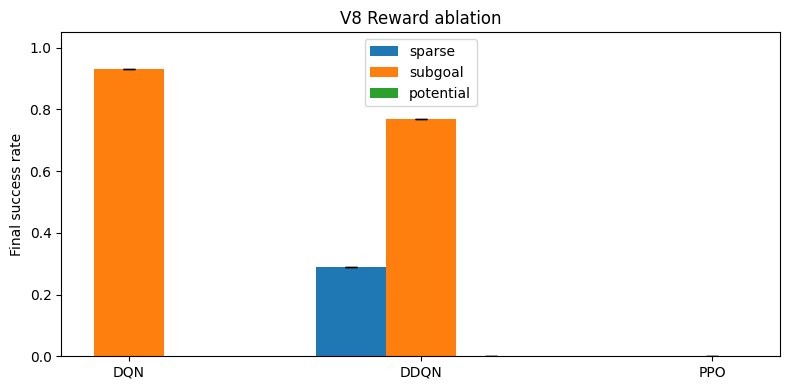

In [10]:
def final_rate(arr, window=100):
    return float(np.mean(arr[-min(window, len(arr)):])) if len(arr) else np.nan

def plot_reward_ablation(runs):
    algos = ["dqn", "ddqn", "ppo"]
    rewards = ["sparse", "subgoal", "potential"]
    x = np.arange(len(algos))
    width = 0.24
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, reward in enumerate(rewards):
        means, stds = [], []
        for algo in algos:
            vals = [final_rate(r["success"]) for r in runs if r["algo"] == algo and r["reward"] == reward]
            means.append(np.mean(vals) if vals else np.nan)
            stds.append(np.std(vals) if vals else 0.0)
        ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=4, label=reward)
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in algos])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Final success rate")
    ax.set_title("V8 Reward ablation")
    ax.legend()
    fig.tight_layout()
    return fig

fig = plot_reward_ablation(runs)
fig.savefig(figure_path(f"p2_{MODE}", "v8_reward_ablation"), dpi=150)
plt.show()

## V9 - Oracle Trajectory With Subgoal Markers

This uses the BFS oracle route as a clean reference. Replace `path` with a saved successful agent path when comparing learned behaviour.

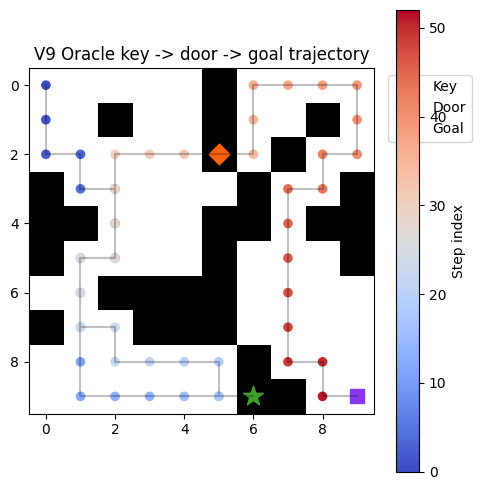

In [11]:
def plot_oracle_trajectory():
    env = DoorKeyMazeEnv(level="small", difficulty="medium", seed=42, reward_type="subgoal")
    maze_free = env.base_maze.copy()
    maze_free[env.door_pos] = 0
    p1 = env._shortest_path_on(maze_free, env.start_pos, env.key_pos)
    p2 = env._shortest_path_on(maze_free, env.key_pos, env.door_pos)[1:]
    p3 = env._shortest_path_on(maze_free, env.door_pos, env.goal_pos)[1:]
    path = p1 + p2 + p3
    rows = [p[0] for p in path]
    cols = [p[1] for p in path]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(env.base_maze, cmap="gray_r", vmin=0, vmax=1)
    scatter = ax.scatter(cols, rows, c=np.arange(len(path)), cmap="coolwarm", s=35)
    ax.plot(cols, rows, color="black", alpha=0.25)
    ax.scatter([env.key_pos[1]], [env.key_pos[0]], c="#40a02b", marker="*", s=220, label="Key")
    ax.scatter([env.door_pos[1]], [env.door_pos[0]], c="#fe640b", marker="D", s=110, label="Door")
    ax.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="#8839ef", marker="s", s=90, label="Goal")
    ax.set_title("V9 Oracle key -> door -> goal trajectory")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.colorbar(scatter, ax=ax, label="Step index")
    fig.tight_layout()
    return fig

fig = plot_oracle_trajectory()
fig.savefig(figure_path(f"p2_{MODE}", "v9_oracle_trajectory"), dpi=150)
plt.show()

## V10 - Learned Agent Key -> Door -> Goal Rollout

Load the best Phase 2 model (`DQN + subgoal`) and save a successful greedy rollout as a GIF.

success: True attempt: 0 frames: 45
key: 1 door: 1 steps: 44
key_pos: (6, 0) door_pos: (3, 6) goal_pos: (9, 9)
saved: C:\Users\pc cam dz\Desktop\RL project\results\videos\p2_quick_dqn_subgoal_small_medium_seed0_greedy_rollout.gif


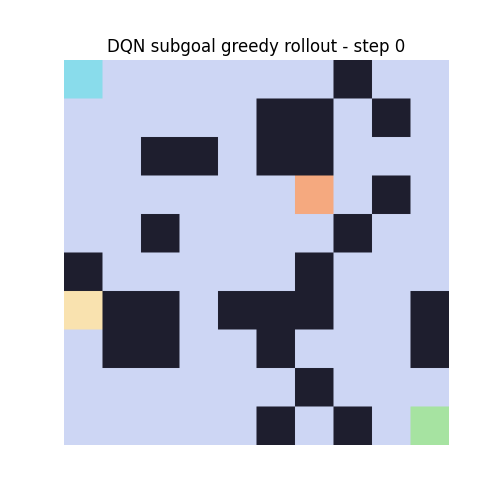

In [12]:
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter
import torch

from src.training.trainer_phase2 import build_q_network, DQN_CFG

BEST_RUN_ID = "p2_quick_dqn_subgoal_small_medium_seed0"
model_path = DIRS["models_dqn"] / f"{BEST_RUN_ID}.pt"
video_path = DIRS["videos"] / f"{BEST_RUN_ID}_greedy_rollout.gif"
DIRS["videos"].mkdir(parents=True, exist_ok=True)

env = DoorKeyMazeEnv(level="small", difficulty="medium", seed=42, reward_type="subgoal", dynamic_objects=True, n_dynamic_layouts=4)
model = build_q_network(env.observation_space.shape[0], DQN_CFG["hidden"], env.action_space.n)
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

def greedy_rollout_frames(env, model, max_attempts=80):
    best = None
    for attempt in range(max_attempts):
        obs, info = env.reset(seed=attempt)
        frames = [env._render_rgb().copy()]
        positions = [env.agent_pos]
        final_info = info

        for _ in range(env.max_steps):
            state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                action = int(model(state).argmax(1).item())
            obs, reward, terminated, truncated, final_info = env.step(action)
            frames.append(env._render_rgb().copy())
            positions.append(env.agent_pos)
            if terminated or truncated:
                break

        score = (int(final_info.get("picked_up_key", 0)), int(final_info.get("opened_door", 0)), int(terminated), -len(frames))
        if best is None or score > best[0]:
            best = (score, frames, positions, final_info, terminated, attempt)
        if terminated:
            return frames, positions, final_info, attempt, True

    _, frames, positions, final_info, terminated, attempt = best
    return frames, positions, final_info, attempt, False

frames, positions, info, attempt, success = greedy_rollout_frames(env, model)
print("success:", success, "attempt:", attempt, "frames:", len(frames))
print("key:", info.get("picked_up_key"), "door:", info.get("opened_door"), "steps:", info.get("steps_taken"))
print("key_pos:", info.get("key_pos"), "door_pos:", info.get("door_pos"), "goal_pos:", info.get("goal_pos"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0])
ax.set_axis_off()
title = ax.set_title("DQN subgoal greedy rollout")

def update(frame_idx):
    im.set_data(frames[frame_idx])
    title.set_text(f"DQN subgoal greedy rollout - step {frame_idx}")
    return [im, title]

anim = FuncAnimation(fig, update, frames=len(frames), interval=120, blit=False)
anim.save(video_path, writer=PillowWriter(fps=8))
plt.close(fig)

print("saved:", video_path)
display(Image(filename=str(video_path)))

## Optional - Phase 1 Vs Phase 2 Sparse DQN

In [13]:
def load_success_rate(path):
    data = np.load(path)
    return final_rate(data["success"])

phase1_files = sorted(DIRS["metrics"].glob("dqn_*_metrics.npz"))
phase2_files = sorted(DIRS["metrics"].glob(f"p2_{MODE}_dqn_sparse_*_metrics.npz"))

if phase1_files and phase2_files:
    p1 = [load_success_rate(p) for p in phase1_files]
    p2 = [load_success_rate(p) for p in phase2_files]
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar([0, 1], [np.mean(p1), np.mean(p2)], yerr=[np.std(p1), np.std(p2)], capsize=5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Phase 1", "Phase 2"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Sparse DQN final success")
    ax.set_title("V10 Phase 1 vs Phase 2")
    fig.tight_layout()
    fig.savefig(figure_path(f"p2_{MODE}", "v10_phase1_vs_phase2"), dpi=150)
    plt.show()
else:
    print("Need at least one Phase 1 DQN metrics file and one Phase 2 sparse DQN metrics file.")
    print("Phase 1 candidates:", [p.name for p in phase1_files])
    print("Phase 2 candidates:", [p.name for p in phase2_files])

Need at least one Phase 1 DQN metrics file and one Phase 2 sparse DQN metrics file.
Phase 1 candidates: []
Phase 2 candidates: []
